## VAE for Image-to-Image Translation
***
In this notebook, we utilize a Conditional Variational Autoencoder (CVAE) to perform supervised image-to-image translation between cats and dogs. VAEs learn a compressed latent representation and reconstruct images through learned encoding and decoding pathways.

The key advantage of VAEs is their efficiency: a single forward pass produces a complete output, enabling real-time inference. By conditioning on class labels, we train a single model that learns to generate both species and perform controlled translation by interpolating or swapping latent codes.


### 1. Dataset Loaders
The dataloaders provide images normalized to [-1, 1] range, matching the output activation function (Tanh) and improving training stability.

We organize data into standard Training and Validation sets with mixed batches of images and their corresponding class labels (Cat=0, Dog=1). This supervised structure enables the model to learn a class-conditional distribution p(x|y), allowing the VAE to control which species is generated via the label input.

In [ ]:
import os
import numpy as np
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

IMG_SIZE=64

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Scale to [-1, 1]
    ])


def get_dataloaders(data_dir, batch_size=24, shuffle=True, transform=transform):
    # Load the full dataset
    full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)
    g = torch.Generator()
    g.manual_seed(42)
    # Filter for only Cats (label 0) and Dogs (label 1) 
    indices = [i for i, (_, label) in enumerate(full_dataset.samples) if label in [0, 1]]
    cat_dog_dataset = Subset(full_dataset, indices)
    
    loader = DataLoader(cat_dog_dataset, batch_size=batch_size, shuffle=shuffle, num_workers=2, generator=g)
    return loader, full_dataset.classes

Using device: cuda


In [8]:
import matplotlib.pyplot as plt
import numpy as np

def show_batch(dataloader, classes):
    images, labels = next(iter(dataloader))
    
    # Un-normalize for visualization
    images = images * 0.5 + 0.5 
    
    plt.figure(figsize=(12, 6))
    for i in range(8):
        plt.subplot(2, 4, i + 1)
        plt.imshow(np.transpose(images[i].numpy(), (1, 2, 0)))
        plt.title(f"Label: {classes[labels[i]]}")
        plt.axis('off')
    plt.show()

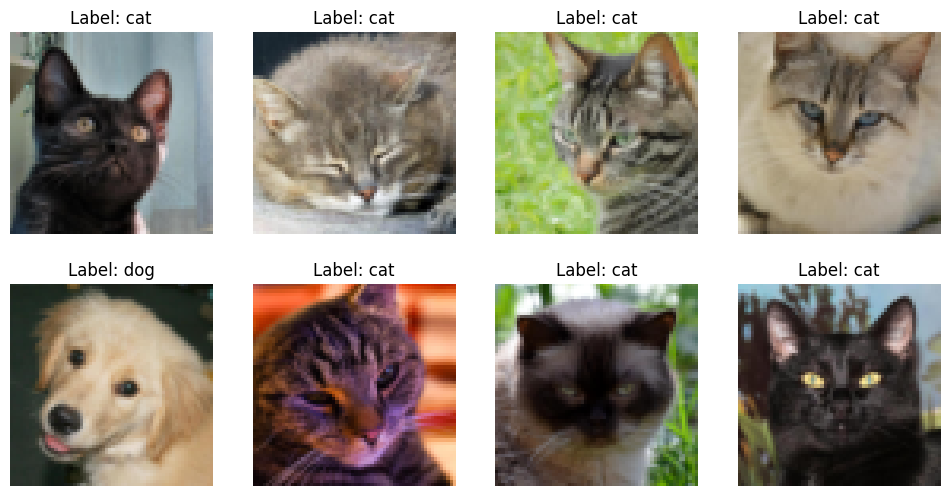

In [ ]:
# Setup
train_loader, train_classes = get_dataloaders("./afhq/train")
show_batch(train_loader, train_classes)

### 2. VAE Architecture Definition

The architecture chosen is a Conditional Variational Autoencoder optimized for 64×64 image generation. Unlike a standard VAE, it injects class information at both the encoder and decoder to allow for specific species generation (Cat vs. Dog).

Mechanism: In the Encoder, the class label is broadcast spatially and concatenated as a 4th input channel, allowing the network to extract features conditioned on the class. We use Strided Convolutions (kernel 4, stride 2) instead of pooling layers to preserve high-frequency texture details (fur/whiskers). The Decoder receives the sampled latent vector (z) concatenated with a learned Class Embedding (dim=64). It progressively upsamples using Transposed Convolutions and LeakyReLU activations. The final output layer uses a Tanh activation to strictly map pixel values to the normalized range [−1,1].

Data Flow & Dimensions:

Input: Image (3,64,64) + Label Plane -> Encoder (4 Layers) -> Flatten

Latent Space: μ,logσ (Linear) -> Reparameterize (z ∈ R^128)

Decode: z + Label Emb (64) -> Decoder (4 Layers) -> Tanh -> Output (3,64,64)

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SharpCVAE(nn.Module):
    def __init__(self, latent_dim=128, num_classes=2, img_channels=3):
        super(SharpCVAE, self).__init__()
        self.latent_dim = latent_dim
        
        self.label_emb = nn.Embedding(num_classes, 64)
        
        # Encoder
        # Input is Image (3) + Label Plane (1) = 4 channels
        self.encoder = nn.Sequential(
            nn.Conv2d(img_channels + 1, 64, 4, 2, 1), # 64x64 -> 32x32
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(64, 128, 4, 2, 1), # 32x32 -> 16x16
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(128, 256, 4, 2, 1), # 16x16 -> 8x8
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(256, 512, 4, 2, 1), # 8x8 -> 4x4
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
        )
        
        self.flatten_dim = 512 * 4 * 4
        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)
        
        # Decoder
        # Latent (128) + Label Embedding (64) = 192
        self.decoder_input = nn.Linear(latent_dim + 64, self.flatten_dim)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.ConvTranspose2d(64, img_channels, 4, 2, 1),
            nn.Tanh() 
        )

    def encode(self, x, y):
        y_encoded = y.view(-1, 1, 1, 1).float().expand(-1, 1, x.size(2), x.size(3))
        x_cond = torch.cat([x, y_encoded], dim=1)
        out = self.encoder(x_cond)
        out = torch.flatten(out, start_dim=1)
        return self.fc_mu(out), self.fc_logvar(out)

    def reparameterize(self, mu, logvar):
        logvar = torch.clamp(logvar, min=-10, max=10)
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, y):
        y_emb = self.label_emb(y)
        z_cond = torch.cat([z, y_emb], dim=1)
        
        out = self.decoder_input(z_cond)
        out = out.view(-1, 512, 4, 4)
        return self.decoder(out)

    def forward(self, x, y):
        mu, logvar = self.encode(x, y)
        z = self.reparameterize(mu, logvar)
        return self.decode(z, y), mu, logvar

### 3. VAE Loss Function


The VAE objective combines two critical terms that balance reconstruction fidelity with learned latent space structure:

**β-annealing Schedule**: We use cyclic annealing of the KL weight to prevent the model from collapsing to the prior too early. The weight increases linearly over 4 epochs, resets, and repeats. This helps the encoder learn meaningful representations before enforcing strict adherence to the prior.

**Reconstruction Loss (MSE)**: Measures pixel-level accuracy of the decoded image. Encourages the model to faithfully reconstruct input images through the bottleneck.

**KL Divergence Loss**: Penalizes deviation from a standard normal distribution p(z) = N(0, I). This regularizes the learned latent space, preventing posterior collapse (where the model ignores the latent variable) and enabling smooth interpolation between classes.

In [3]:
import torchvision.models as models

def get_kl_weight(epoch, total_epochs):
    # Cyclic Annealing: Linearly increase weight, then reset, then increase again.
    cycle_len = total_epochs // 4
    cycle_idx = epoch % cycle_len
    
    # Target max weight
    max_kl = 0.005 
    
    # Linear ramp up
    weight = (cycle_idx / cycle_len) * max_kl
    return weight
    

def loss_function(recon_x, x, mu, logvar, beta=1.0):
    # Reconstruction loss
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    # KL Divergence
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kld_loss * beta

### 4. Training & Validation Routine


The training loop implements the standard VAE objective: for each batch, we encode images with their labels to obtain μ and log σ², reparameterize to sample z, then decode z with the target label to reconstruct the image.

**Validation**: The validation function mirrors training but uses a fixed KL weight (0.00025) without updating parameters. This monitors the true generalization loss and guides early stopping decisions based on validation performance.

In [ ]:
def train_epoch(model, dataloader, optimizer, device, epoch, num_epochs):
    model.train()
    train_loss = 0
    weight = get_kl_weight(epoch, num_epochs)
    for batch_idx, (data, labels) in enumerate(dataloader):
        data, labels = data.to(device), labels.to(device)
        optimizer.zero_grad()
        
        # Forward pass
        recon_batch, mu, logvar = model(data, labels)
        # Calculate loss
        loss = loss_function(recon_batch, data, mu, logvar, weight)
        
        # Backward pass
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
        
    avg_loss = train_loss / len(dataloader.dataset)
    return avg_loss

def validate_epoch(model, dataloader, device):
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for data, labels in dataloader:
            data, labels = data.to(device), labels.to(device)
            
            recon_batch, mu, logvar = model(data, labels)
            loss = loss_function(recon_batch, data, mu, logvar, 0.00025)
            val_loss += loss.item()
            
    avg_loss = val_loss / len(dataloader.dataset)
    return avg_loss

### 5. Optimization & Execution

**Checkpointing**: We save the model only when validation loss improves, ensuring the final checkpoint represents the best generalization performance rather than the final iteration.

We configure training using the AdamW optimizer with a OneCycleLR scheduler that linearly warms up the learning rate to a peak, then decays it. This scheduling strategy helps escape sharp minima and improves generalization.

- **Epochs**: 40 (typical convergence for AFHQ dataset)

**Key Hyperparameters**:- **Weight Decay**: 1e-4 (mild L2 regularization)

- **Latent Dimension**: 256 (captures diverse cat/dog variations)- **Learning Rate**: 1e-3 (OneCycle peak, starts at 1e-4)

In [ ]:
from copy import deepcopy

train_loader, train_classes = get_dataloaders("./afhq/train")
val_loader, val_classes = get_dataloaders("./afhq/val",shuffle=False)

# Configuration
num_epochs = 40
learning_rate = 1e-3

# Initialize Model and Optimizer
model = SharpCVAE(latent_dim=256).to(device)
# model.load_state_dict(torch.load("cvae_basic_40epochs.pth"))
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)

best_val_loss=np.inf
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-3,
    epochs=num_epochs,
    steps_per_epoch=len(train_loader),
    pct_start=0.3, # Spend 30% of time warming up
    div_factor=10, # Start at max_lr / 10
    final_div_factor=100 # End at max_lr / 100
)
for epoch in range(1, num_epochs + 1):
    # Call training function
    train_loss = train_epoch(model, train_loader, optimizer, device, epoch, num_epochs)
    
    # Call validation function
    val_loss = validate_epoch(model, val_loader, device)
    print(f'Epoch {epoch}: Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')
    scheduler.step(val_loss)
    if val_loss<best_val_loss:
        best_val_loss = val_loss
        print("Saved best model")
        state_dict = deepcopy(model.state_dict())
    
    # torch.save(model.state_dict(), f"cvae_epoch_{epoch}.pth")

### 6. Image Translation & Visualization

After training, we use the VAE for diagnostic evaluation and visualization. However, there are known limitations with this architecture:

**Blurriness**: VAEs with MSE reconstruction loss tend to average over plausible outputs, producing blurry results. This is a fundamental trade-off between reconstruction fidelity and latent space regularity.

**Weak Label Conditioning**: The label injection (as a concatenated channel in the encoder and as an embedding in the decoder) is not strong enough. The decoder often ignores the label signal and reconstructs images close to the original, making cat -> dog translation ineffective. Stronger conditioning techniques (e.g., FiLM-style modulation or separate pathways per class) would be needed.

**Diagnostic Functions**: The visualization functions serve primarily to inspect what the model has learned, not to produce high-quality translations:

- **`naive_generate(model, label)`**: Samples z ~ N(0, I) and decodes with target label. Shows if the decoder learned meaningful representations for each class (often produces blurry, class-indifferent outputs).

- **`smart_generate(model, num_samples, device, label, real_mean, real_std)`**: Samples z from the empirical distribution of training latents (real_mean, real_std) instead of the prior. Produces samples from regions the decoder actually saw during training.

- **`visualize_transformation(model, dataloader, device)`**: Encodes real cats with cat labels, then decodes as dogs. Reveals the extent of label conditioning — successful models show clear species transformation, while weak conditioning shows minimal change (the output looks like the original image).

In [ ]:
def visualize_transformation(model, dataloader, device):
    model.eval()
    
    # Find 5 Cats and 5 Dogs
    cat_indices = []
    dog_indices = []
    
    for i in range(len(dataloader.dataset)):
        _, label = dataloader.dataset[i]
        if int(label) == 0 and len(cat_indices) < 5:
            cat_indices.append(i)
        elif int(label) == 1 and len(dog_indices) < 5:
            dog_indices.append(i)
        if len(cat_indices) >= 5 and len(dog_indices) >= 5:
            break
    
    # Setup Visualization Grid (5 rows, 4 columns)
    fig, axes = plt.subplots(5, 4, figsize=(16, 20))
    fig.suptitle('VAE Cross-Species Translation (Cat↔Dog)', fontsize=20)
    
    # Column titles
    axes[0, 0].set_title("Source (Cat)", fontsize=14)
    axes[0, 1].set_title("Translated (Dog)", fontsize=14)
    axes[0, 2].set_title("Source (Dog)", fontsize=14)
    axes[0, 3].set_title("Translated (Cat)", fontsize=14)
    
    with torch.no_grad():
        for i in range(5):
            # Load Cat and Dog images
            cat_img, cat_lbl = dataloader.dataset[cat_indices[i]]
            dog_img, dog_lbl = dataloader.dataset[dog_indices[i]]
            
            cat_img = cat_img.unsqueeze(0).to(device)  # [1, 3, 64, 64]
            dog_img = dog_img.unsqueeze(0).to(device)
            
            # Cat -> Dog: Encode cat, decode as dog
            cat_mu, _ = model.encode(cat_img, torch.zeros(1, dtype=torch.long).to(device))
            cat_to_dog = model.decode(cat_mu, torch.ones(1, dtype=torch.long).to(device))
            
            # Dog -> Cat: Encode dog, decode as cat
            dog_mu, _ = model.encode(dog_img, torch.ones(1, dtype=torch.long).to(device))
            dog_to_cat = model.decode(dog_mu, torch.zeros(1, dtype=torch.long).to(device))
            
            pairs = [
                (cat_img, True),
                (cat_to_dog, False),
                (dog_img, True),
                (dog_to_cat, False)  
            ]
            
            for col, (tensor_img, is_original) in enumerate(pairs):
                if tensor_img.ndim == 4:
                    tensor_img = tensor_img.squeeze(0)
                
                img_cpu = tensor_img.permute(1, 2, 0).cpu()
                
                show_img = (img_cpu + 1) / 2  # Convert from [-1, 1] to [0, 1]
                
                axes[i, col].imshow(show_img.clamp(0, 1))
                axes[i, col].axis('off')
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.95)
    plt.show()

def naive_generate(model, label):
    z = torch.randn(1, 256).to(device)
    y = torch.tensor([label]).to(device)
    
    # Generate
    recon = model.decode(z, y)
    
    img = recon[0].permute(1, 2, 0).detach().cpu().numpy() * 0.5 + 0.5
    
    plt.imshow(img)
    plt.title(f"Generated Class {label}")
    plt.show()

all_mus = []
with torch.no_grad():
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        mu, _ = model.encode(x, y)
        all_mus.append(mu)

all_mus = torch.cat(all_mus, dim=0)
real_mean = all_mus.mean(dim=0)
real_std = all_mus.std(dim=0)

def smart_generate(model, num_samples, device, label_class, real_mean,real_std):
    # z = real_mean + (noise * real_std)
    z = torch.randn(num_samples, model.latent_dim).to(device)
    z = z * real_std + real_mean
    
    # Decode
    y = torch.full((num_samples,), label_class, dtype=torch.long).to(device)
    recon = model.decode(z, y)
    img = recon[0].permute(1, 2, 0).detach().cpu().numpy() * 0.5 + 0.5
    
    plt.imshow(img)
    plt.title(f"Generated Class {label_class}")
    plt.show()
    return 

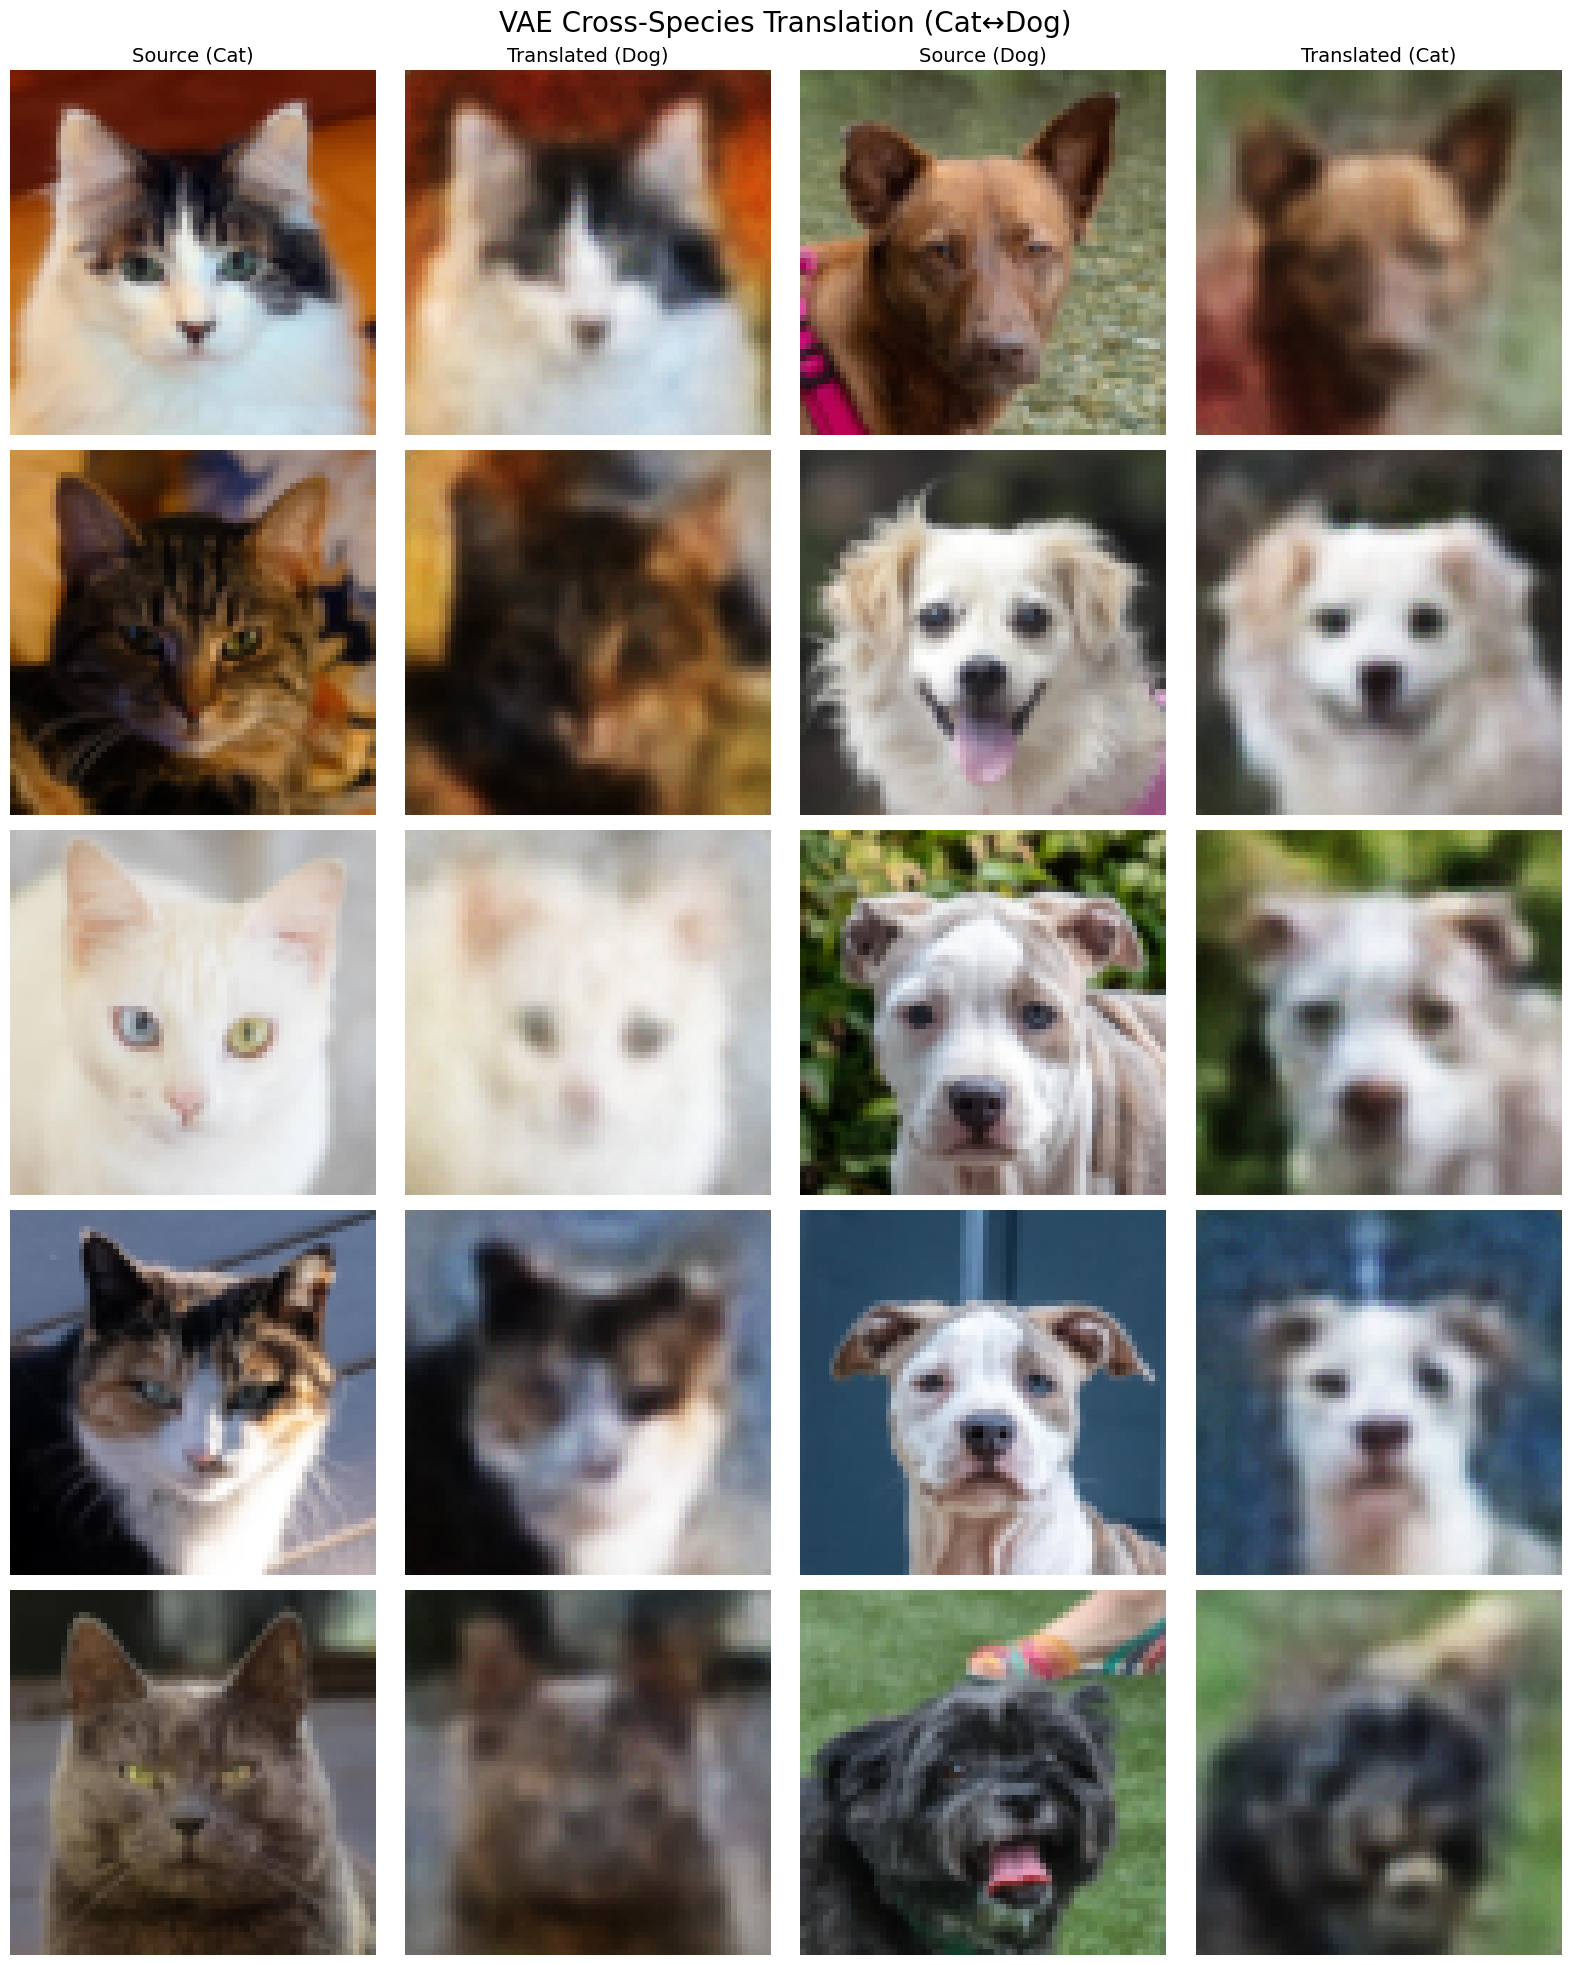

In [ ]:
visualize_transformation(model, val_loader, device)

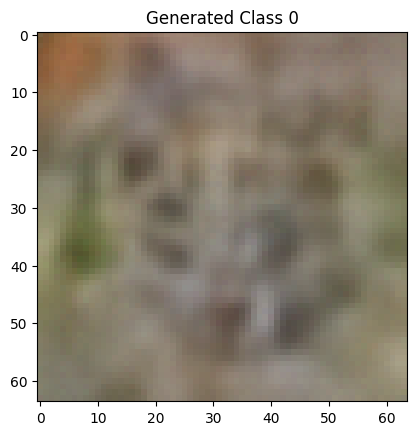

In [12]:
naive_generate(model, 0)

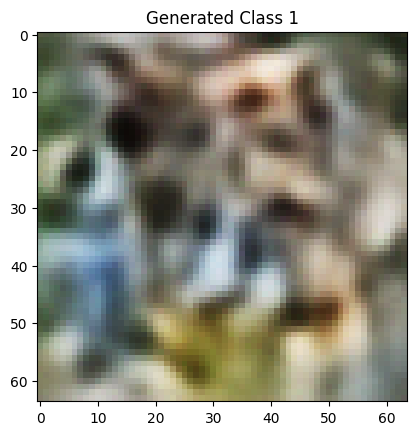

In [ ]:
smart_generate(model, num_samples=1, device=device,label_class=0, real_mean=real_mean, real_std=real_std)

#### References:
***
1. https://medium.com/@sofeikov/implementing-conditional-variational-auto-encoders-cvae-from-scratch-29fcbb8cb08f
#### Tools used:
***
1. Visual Studio Code
2. Google Gemini 2.5
3. Git (versioning)

#### GitHub link:
***
https://github.com/robertbejan/deepavance/tree/main